正在加载清洗后的数据...
生成用户画像分析图表...


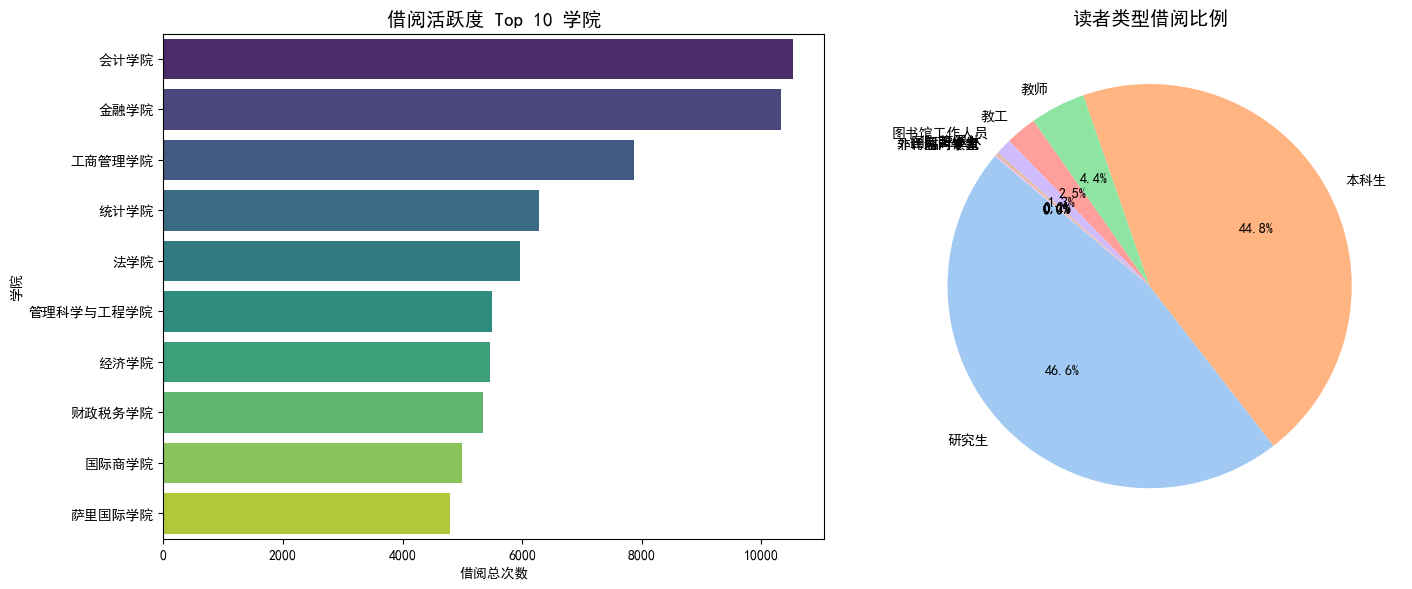

生成图书热度分析图表...


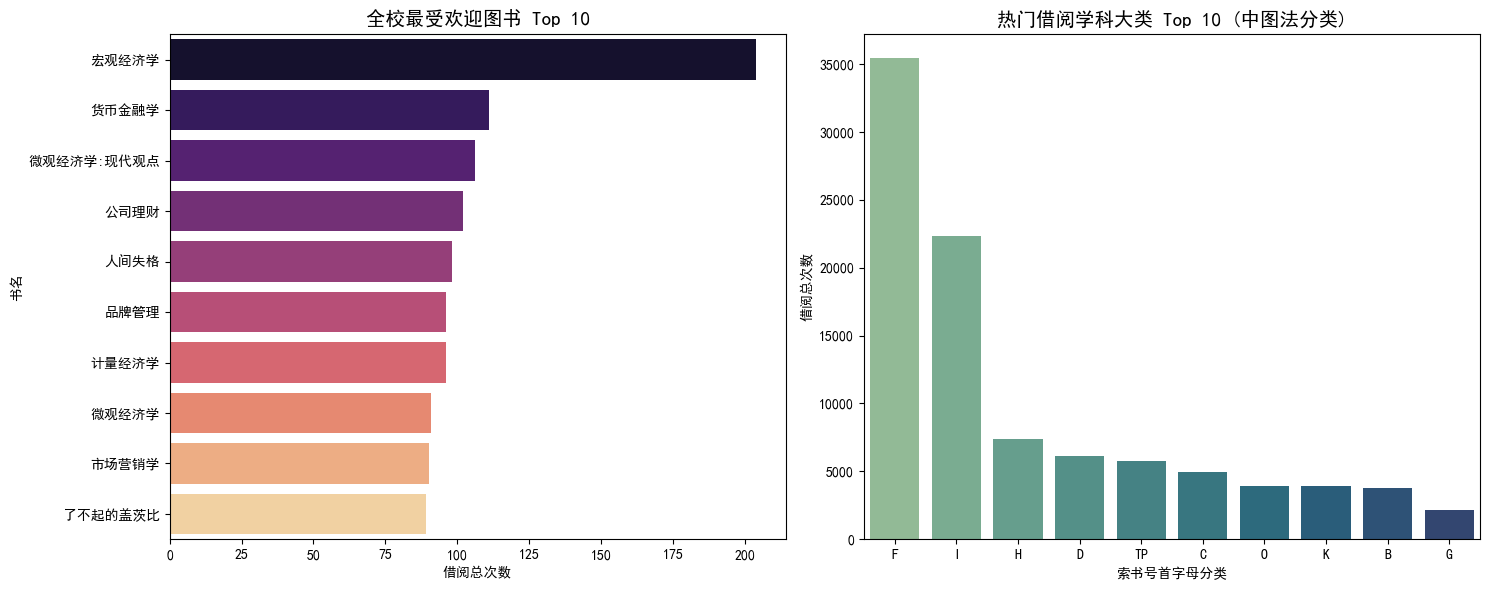

生成时间时序分析图表...


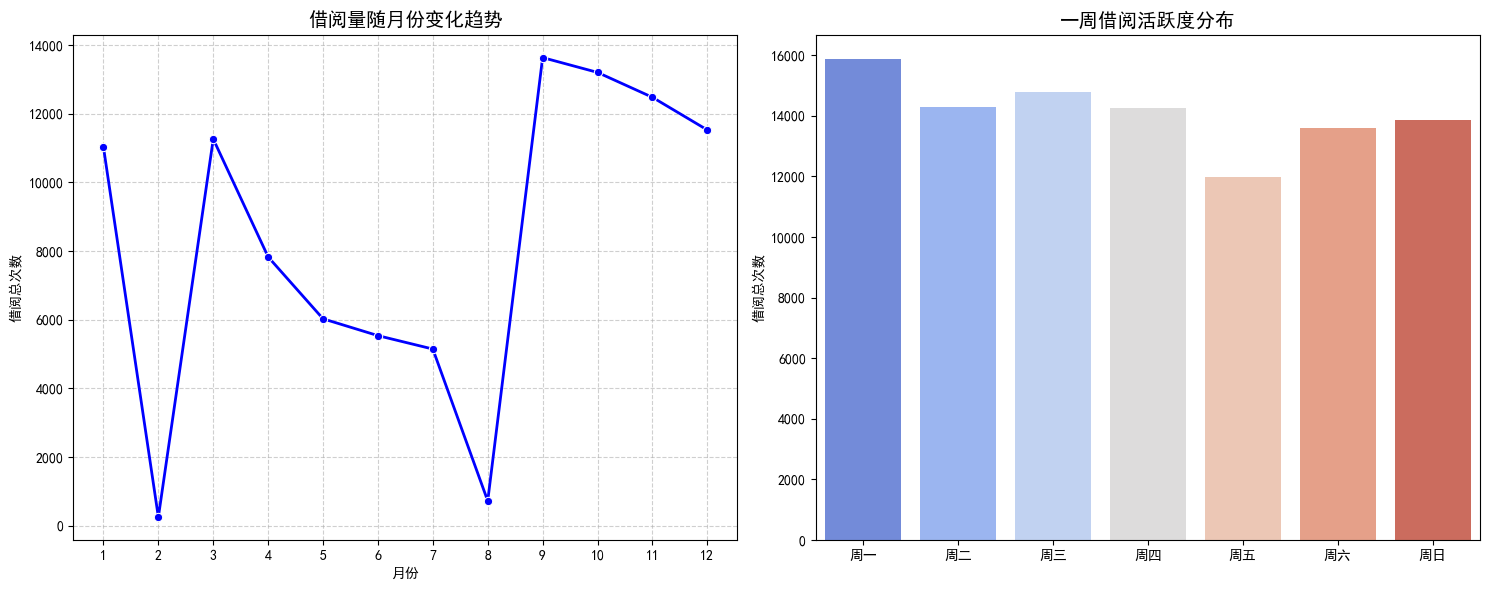

所有 EDA 图表生成完毕，高清图片已保存至 ../data/processed/ 目录。


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略常规警告
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

def load_data(filepath):
    print("正在加载清洗后的数据...")
    return pd.read_csv(filepath)

def plot_user_profile(df):
    """分析用户画像：学院分布与读者类型"""
    plt.figure(figsize=(15, 6))

    # 1. 借阅量 Top 10 学院 (排除 Unknown)
    plt.subplot(1, 2, 1)
    dept_counts = df[df['DEPT'] != 'Unknown']['DEPT'].value_counts().head(10)
    sns.barplot(y=dept_counts.index, x=dept_counts.values, palette='viridis')
    plt.title('借阅活跃度 Top 10 学院', fontsize=14)
    plt.xlabel('借阅总次数')
    plt.ylabel('学院')

    # 2. 读者类型分布 (如本科生、研究生等)
    plt.subplot(1, 2, 2)
    if 'REDR_TYPE_NAME' in df.columns:
        redr_counts = df['REDR_TYPE_NAME'].value_counts()
        plt.pie(redr_counts.values, labels=redr_counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('pastel'), startangle=140)
        plt.title('读者类型借阅比例', fontsize=14)

    plt.tight_layout()
    plt.savefig('../data/processed/images/eda_user_profile.png', dpi=300)
    plt.show()

def plot_book_popularity(df):
    """分析图书热度：最受欢迎图书与学科大类"""
    plt.figure(figsize=(15, 6))

    # 1. 借阅量 Top 10 具体图书 (排除无书名的记录)
    plt.subplot(1, 2, 1)
    book_counts = df[df['TITLE'].notnull()]['TITLE'].value_counts().head(10)
    sns.barplot(y=book_counts.index, x=book_counts.values, palette='magma')
    plt.title('全校最受欢迎图书 Top 10', fontsize=14)
    plt.xlabel('借阅总次数')
    plt.ylabel('书名')

    # 2. 学科大类分布 (提取索书号 CALL_NO 的首字母作为大类)
    # 比如 F 代表经济，I 代表文学，TP 代表计算机
    plt.subplot(1, 2, 2)
    df['SUBJECT_CATEGORY'] = df['CALL_NO'].astype(str).str.extract(r'([A-Za-z]+)')
    subject_counts = df['SUBJECT_CATEGORY'].value_counts().head(10)
    sns.barplot(x=subject_counts.index, y=subject_counts.values, palette='crest')
    plt.title('热门借阅学科大类 Top 10 (中图法分类)', fontsize=14)
    plt.xlabel('索书号首字母分类')
    plt.ylabel('借阅总次数')

    plt.tight_layout()
    plt.savefig('../data/processed/images/eda_book_popularity.png', dpi=300)
    plt.show()

def plot_time_trends(df):
    """分析时间趋势：月份分布与星期分布"""
    plt.figure(figsize=(15, 6))

    # 1. 月份借阅趋势 (反映学期周期)
    plt.subplot(1, 2, 1)
    month_counts = df.groupby('LEND_MONTH').size()
    sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o', color='b', linewidth=2)
    plt.title('借阅量随月份变化趋势', fontsize=14)
    plt.xlabel('月份')
    plt.ylabel('借阅总次数')
    plt.xticks(range(1, 13))
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. 星期借阅分布
    plt.subplot(1, 2, 2)
    day_counts = df['LEND_DAYOFWEEK'].value_counts().sort_index()
    days_labels = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
    sns.barplot(x=days_labels, y=day_counts.values, palette='coolwarm')
    plt.title('一周借阅活跃度分布', fontsize=14)
    plt.ylabel('借阅总次数')

    plt.tight_layout()
    plt.savefig('../data/processed/images/eda_time_trends.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    # 读取第一阶段清洗好的数据
    df_cleaned = load_data('../data/processed/LENDHIST2019_2020_cleaned.csv')

    print("生成用户画像分析图表...")
    plot_user_profile(df_cleaned)

    print("生成图书热度分析图表...")
    plot_book_popularity(df_cleaned)

    print("生成时间时序分析图表...")
    plot_time_trends(df_cleaned)

    print("所有 EDA 图表生成完毕，高清图片已保存至 ../data/processed/images/ 目录。")

正在加载数据并进行学科与时段映射...
正在生成独立的可视化图表...


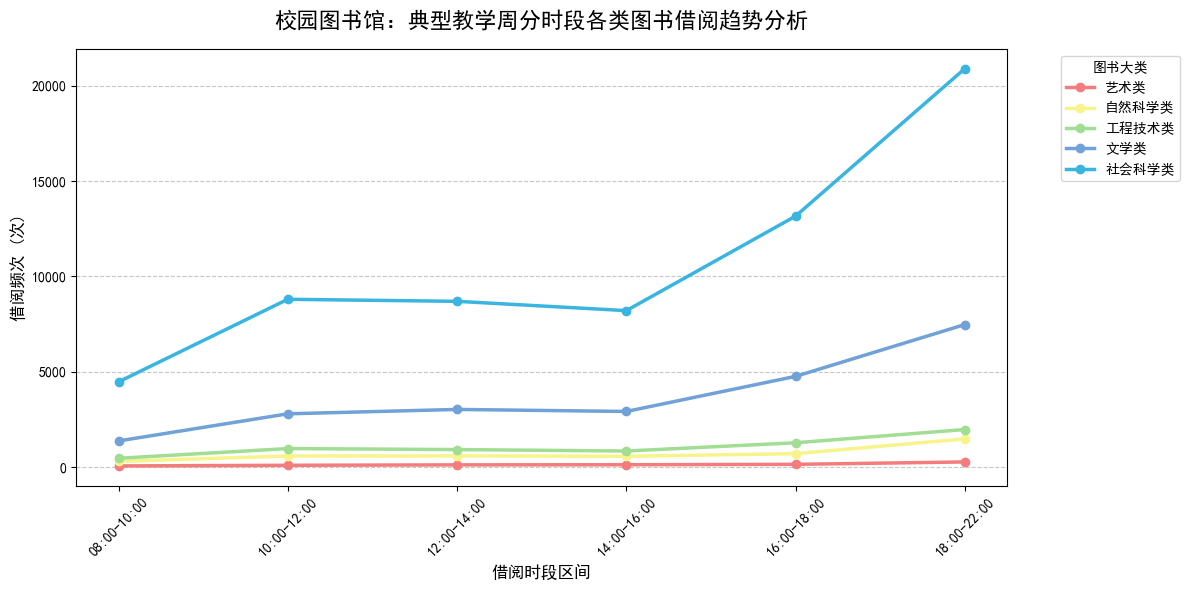

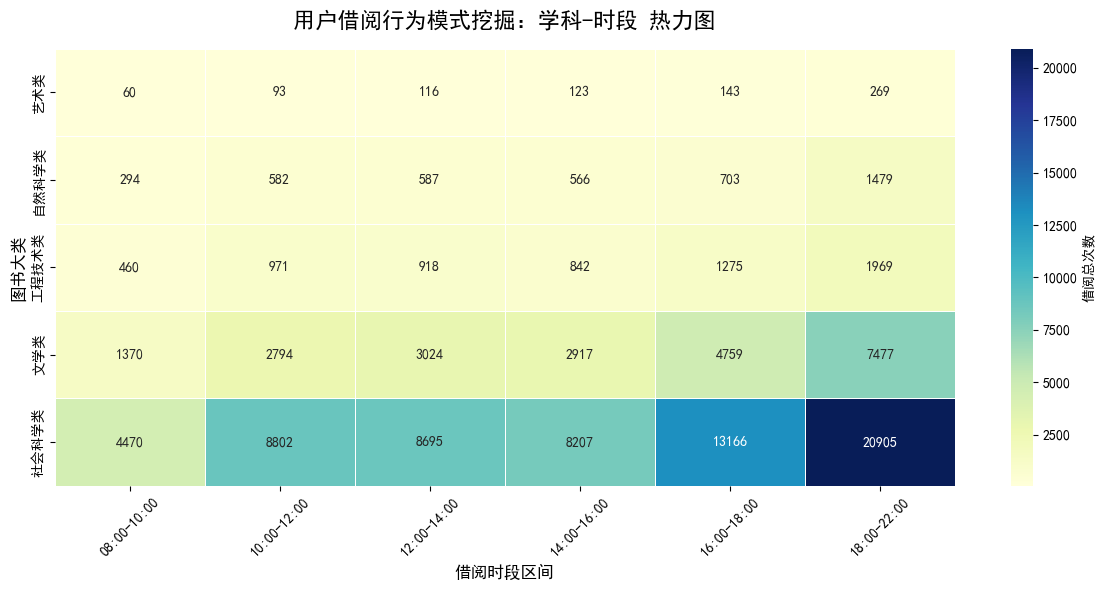

- 折线图已保存至: '../data/processed/images/eda_borrowing_trend_line.png'
- 热力图已保存至: '../data/processed/images/eda_behavior_heatmap.png'


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs('../data/processed/images', exist_ok=True)

# ----------------- 图表环境设置 -----------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("正在加载数据并进行学科与时段映射...")
df = pd.read_csv('../data/processed/LENDHIST2019_2020_cleaned.csv')

# ==========================================
# 步骤 1：特征工程 - 映射 5 大学科类别与时段分箱
# ==========================================
def map_clc_to_broad_category(call_no):
    """将中图法索书号首字母映射为论文中的 5 大类"""
    if pd.isna(call_no) or str(call_no).strip() == '':
        return '其他'
    letter = str(call_no).strip()[0].upper()

    if letter == 'I':
        return '文学类'
    elif letter == 'J':
        return '艺术类'
    elif letter in ['N', 'O', 'P', 'Q']:
        return '自然科学类'
    elif letter in ['T', 'U', 'V', 'X']:
        return '工程技术类'
    elif letter in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'K']:
        return '社会科学类'
    else:
        return '其他'

df['BROAD_CATEGORY'] = df['CALL_NO'].apply(map_clc_to_broad_category)
df_filtered = df[(df['LEND_HOUR'] >= 8) & (df['LEND_HOUR'] < 22)].copy()

bins = [8, 10, 12, 14, 16, 18, 22]
labels = ['08:00-10:00', '10:00-12:00', '12:00-14:00', '14:00-16:00', '16:00-18:00', '18:00-22:00']
df_filtered['TIME_PERIOD'] = pd.cut(df_filtered['LEND_HOUR'], bins=bins, labels=labels, right=False)

pivot_df = pd.crosstab(df_filtered['BROAD_CATEGORY'], df_filtered['TIME_PERIOD'])
if '其他' in pivot_df.index:
    pivot_df = pivot_df.drop('其他')

pivot_df = pivot_df.sort_values(by='14:00-16:00', ascending=True)

# ==========================================
# 步骤 2：独立生成两张可视化图表
# ==========================================
print("正在生成独立的可视化图表...")

# ----------------- 图 1：折线图 -----------------
plt.figure(figsize=(12, 6))
colors = ['#f47c7c', '#f7f48b', '#a1de93', '#70a1d7', '#39b5e0']

for i, category in enumerate(pivot_df.index):
    plt.plot(pivot_df.columns, pivot_df.loc[category], marker='o', linewidth=2.5,
             label=category, color=colors[i % len(colors)])

plt.title('校园图书馆：典型教学周分时段各类图书借阅趋势分析', fontsize=16, pad=15)
plt.xlabel('借阅时段区间', fontsize=12)
plt.ylabel('借阅频次 (次)', fontsize=12)
plt.legend(title='图书大类', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/images/eda_borrowing_trend_line.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ----------------- 图 2：热力图 -----------------
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=True, fmt="d", cmap="YlGnBu",
            linewidths=.5, cbar_kws={'label': '借阅总次数'})

plt.title('用户借阅行为模式挖掘：学科-时段 热力图', fontsize=16, pad=15)
plt.xlabel('借阅时段区间', fontsize=12)
plt.ylabel('图书大类', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/images/eda_behavior_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("- 折线图已保存至: '../data/processed/images/eda_borrowing_trend_line.png'")
print("- 热力图已保存至: '../data/processed/images/eda_behavior_heatmap.png'")

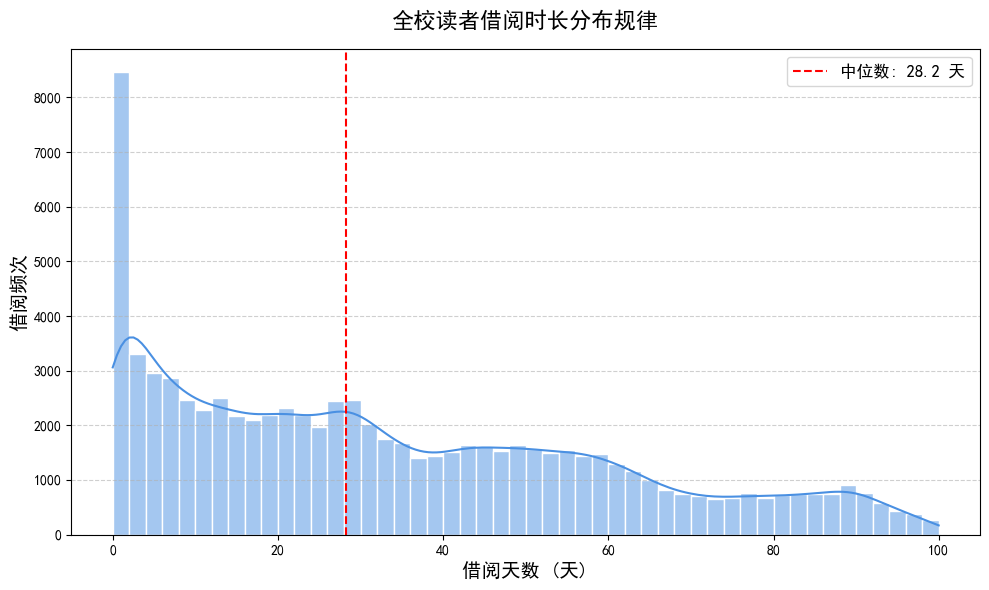

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 加载数据
df = pd.read_csv('../data/processed/LENDHIST2019_2020_cleaned.csv')

# ==========================================
#  借阅时长分布图 (KDE + Histogram)
# ==========================================
plt.figure(figsize=(10, 6))
# 过滤掉未归还的或异常时长的
valid_days = df[(df['LEND_DAYS'] > 0) & (df['LEND_DAYS'] < 100)]['LEND_DAYS']

sns.histplot(valid_days, bins=50, kde=True, color='#4A90E2', edgecolor='white')
plt.title('全校读者借阅时长分布规律', fontsize=16, pad=15)
plt.xlabel('借阅天数 (天)', fontsize=14)
plt.ylabel('借阅频次', fontsize=14)
plt.axvline(valid_days.median(), color='red', linestyle='--', label=f'中位数: {valid_days.median():.1f} 天')
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../data/processed/images/eda_lend_days_dist.png', dpi=300)
plt.show()

正在加载数据并进行共现分析...
共提取到 22949 组有效的多本借阅记录。


C:\Users\86138\AppData\Local\Temp\ipykernel_21068\2658724655.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pair_counts, y=pair_names, palette='viridis')


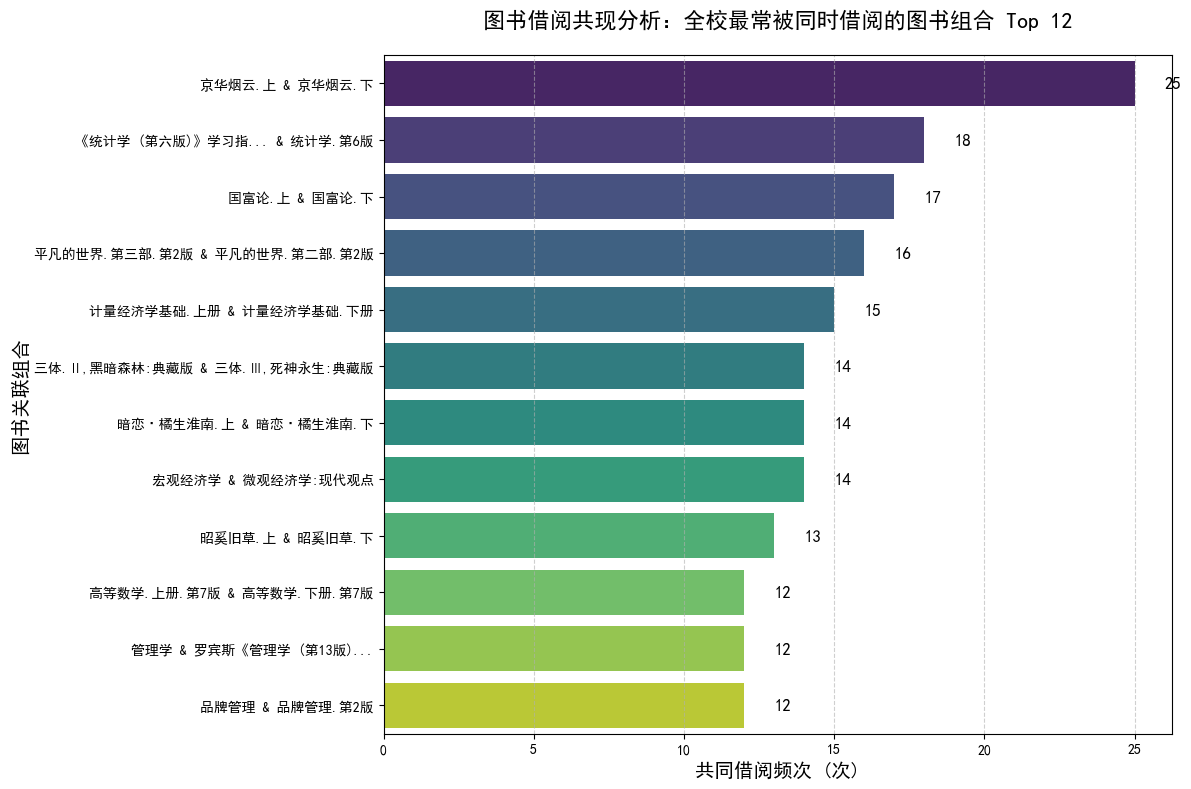


✅ 图书共现分析条形图已成功生成并保存至 '../data/processed/images/eda_book_cooccurrence.png'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

# ==========================================
# 绘图基础设置：防止中文和负号显示乱码
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("正在加载数据并进行共现分析...")

# 1. 加载清洗后的数据
df = pd.read_csv('../data/processed/LENDHIST2019_2020_cleaned.csv')

# 过滤掉没有书名的异常记录
df = df.dropna(subset=['TITLE'])

# 2. 提取纯日期：因为同一次借多本书在时间戳上可能有几秒误差，所以按“同一天”来聚合
df['LEND_DATE_ONLY'] = pd.to_datetime(df['LEND_DATE']).dt.date

# 3. 构建“借阅篮子” (Basket)
# 按“用户ID”和“借阅日期”分组，把该用户这一天借的所有书名放进一个列表
# 使用 set 去重，防止把同一本书的多个复本算作共现
basket_df = df.groupby(['USERID', 'LEND_DATE_ONLY'])['TITLE'].apply(lambda x: list(set(x))).reset_index()

# 过滤掉当天只借了 1 本书的记录（1本书无法形成组合）
baskets = basket_df[basket_df['TITLE'].apply(len) > 1]['TITLE'].tolist()

print(f"共提取到 {len(baskets)} 组有效的多本借阅记录。")

# 4. 统计图书的共现对 (Pairs)
pair_counter = Counter()

for basket in baskets:
    # 将篮子里的书名按字母/拼音排序，确保 (书A, 书B) 和 (书B, 书A) 被算作同一种组合
    sorted_basket = sorted(basket)
    # 提取两两组合
    pairs = combinations(sorted_basket, 2)
    pair_counter.update(pairs)

# 5. 获取全校最常被一起借阅的 Top 12 图书组合
top_pairs = pair_counter.most_common(12)

# 为了绘图美观，如果书名太长会遮挡，写一个简单的截断函数
def truncate_title(title, max_len=14):
    return title if len(title) <= max_len else title[:max_len] + "..."

# 提取 Y 轴标签和 X 轴数据
pair_names = [f"{truncate_title(pair[0][0])} & {truncate_title(pair[0][1])}" for pair in top_pairs]
pair_counts = [pair[1] for pair in top_pairs]

# 6. 绘制水平条形图
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=pair_counts, y=pair_names, palette='viridis')

# 设置标题和标签
plt.title('图书借阅共现分析：全校最常被同时借阅的图书组合 Top 12', fontsize=16, pad=20)
plt.xlabel('共同借阅频次 (次)', fontsize=14)
plt.ylabel('图书关联组合', fontsize=14)

# 在柱状图右侧添加具体的数值标签，方便直观读取
for i, v in enumerate(pair_counts):
    ax.text(v + 1, i, str(v), color='black', va='center', fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存高质量图片供论文使用
save_path = '../data/processed/images/eda_book_cooccurrence.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ 图书共现分析条形图已成功生成并保存至 '{save_path}'")